In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

In [16]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

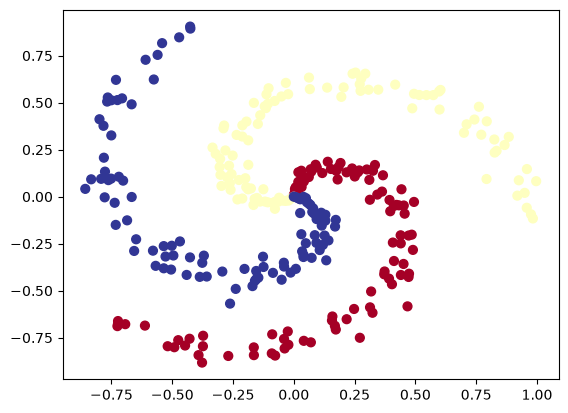

In [10]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100
K = 3
D = 2
X = np.zeros((N*K,D))
y = np.zeros(N*K, dtype = "uint8" )
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

plt.scatter(X[: , 0], X[: , 1],c=y, s=40,cmap=plt.cm.RdYlBu)
plt.show()

In [11]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

In [12]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X,y,train_size = 0.8 , random_state = RANDOM_SEED)
len(X_train), len(X_test), len(Y_train), len(Y_test)

(240, 60, 240, 60)

In [18]:
from torchmetrics import Accuracy
acc_fn = Accuracy(task = "multiclass", num_classes = 3).to("cpu")
acc_fn

MulticlassAccuracy()

In [33]:
class SpiralModel(nn.Module):
    def __init__ (self):
        super().__init__()
        self.linear1 = nn.Linear(in_features = 2, out_features = 10)
        self.linear2 = nn.Linear(in_features = 10, out_features = 10)
        self.linear3 = nn.Linear(in_features = 10, out_features = 3)
        self.relu = nn.ReLU()

    def forward(self , x):
        return self.linear3(self.relu(self.linear2(self.relu(self.linear1(x)))))

model_1 = SpiralModel().to("cpu")
model_1


SpiralModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [34]:
X_train , Y_train = X_train.to("cpu") , Y_train.to("cpu")
X_test , Y_test = X_test.to("cpu") , Y_test.to("cpu")
print(X_train.dtype , Y_train.dtype , X_test.dtype , Y_test.dtype)

torch.float32 torch.int64 torch.float32 torch.int64


In [45]:
def plot_decision_boundary(model, X, y):

    # Put model and data on CPU
    model.to("cpu")
    X = X.to("cpu")
    y = y.to("cpu")

    # Create grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 101),
        np.linspace(y_min, y_max, 101)
    )

    # Convert grid into input features
    X_to_pred_on = torch.from_numpy(
        np.column_stack((xx.ravel(), yy.ravel()))
    ).float()

    # Make predictions
    model.eval()

    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

        y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    # Reshape predictions
    y_pred = y_pred.reshape(xx.shape).numpy()

    # Plot decision regions
    plt.contourf(
        xx,
        yy,
        y_pred,
        cmap=plt.cm.RdYlBu,
        alpha=0.7
    )

    # Plot actual data
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        s=40,
        cmap=plt.cm.RdYlBu
    )

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

In [35]:
print(f"Logits: {model_1(X_train)[:10]}")
print(f"pred_probs: {torch.softmax(model_1(X_train)[:10], dim=1)}")
print(f"pred_labels: {torch.softmax(model_1(X_train)[:10], dim=1).argmax(dim=1)}")

Logits: tensor([[-0.1856,  0.0278,  0.0008],
        [-0.1899,  0.0235,  0.0021],
        [-0.1334,  0.0216, -0.0221],
        [-0.0877,  0.0751, -0.0898],
        [-0.0893,  0.0770, -0.0874],
        [-0.1171,  0.0361, -0.0395],
        [-0.1209,  0.0302, -0.0335],
        [-0.1958,  0.0327, -0.0109],
        [-0.1403,  0.0209, -0.0202],
        [-0.0867,  0.0761, -0.0912]], grad_fn=<SliceBackward0>)
pred_probs: tensor([[0.2905, 0.3596, 0.3500],
        [0.2899, 0.3589, 0.3513],
        [0.3044, 0.3554, 0.3402],
        [0.3150, 0.3707, 0.3143],
        [0.3142, 0.3710, 0.3148],
        [0.3081, 0.3590, 0.3329],
        [0.3073, 0.3574, 0.3353],
        [0.2890, 0.3632, 0.3477],
        [0.3028, 0.3558, 0.3414],
        [0.3152, 0.3709, 0.3138]], grad_fn=<SoftmaxBackward0>)
pred_labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [36]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters() , lr = 0.02)

In [40]:
epochs = 1000

for epoch in range (epochs):
    model_1.train()

    y_logits = model_1(X_train)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss = loss_fn(y_logits , Y_train)
    acc = acc_fn(y_pred , Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim = 1)

        test_loss = loss_fn(test_logits , Y_test)
        test_acc = acc_fn(test_pred , Y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 100 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 200 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 300 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 400 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 500 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 600 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 700 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 800 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00
Epoch: 900 | Loss: 0.01 Acc: 0.99 | Test loss: 0.00 Test acc: 1.00


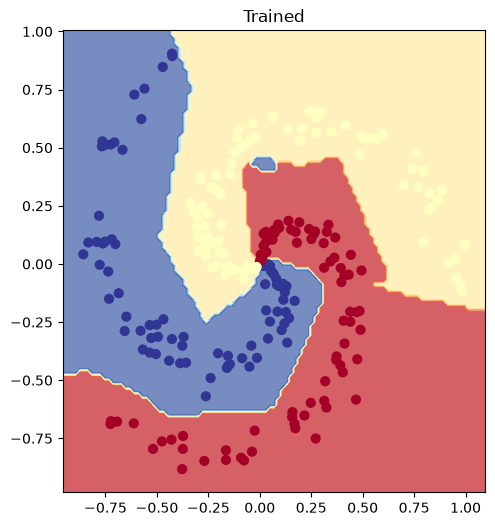

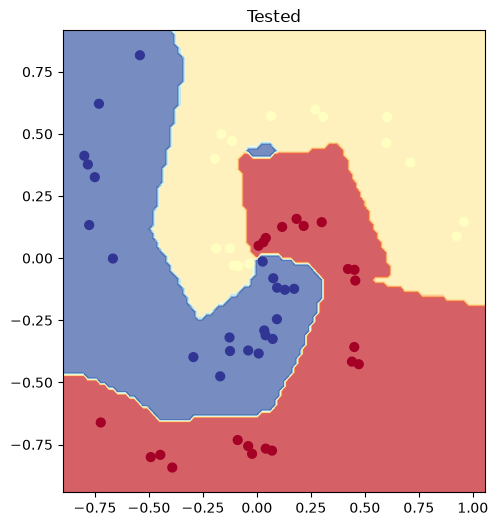

In [48]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Trained")
plot_decision_boundary(model_1 , X_train , Y_train)

plt.figure(figsize = (12,6))
plt.subplot(1,2,2)
plt.title("Tested")
plot_decision_boundary(model_1 , X_test , Y_test)